# **Comparison between simple gemini prompting setup vs Kreuzberg + gemini prompting setup**

In [12]:
!pip install -q google-generativeai kreuzberg

In [13]:
from google.colab import files

uploaded = files.upload()

Saving CV_SamuelHanok_DataScientist.pdf to CV_SamuelHanok_DataScientist (1).pdf


In [14]:
from google.colab import userdata
import google.generativeai as genai

GOOGLE_API_KEY = userdata.get('GOOGLE_API_KEY')

genai.configure(api_key=GOOGLE_API_KEY)

In [15]:
model = genai.GenerativeModel("gemini-2.5-flash")

# **SETUP 1 : Sending Raw PDF Directly to Gemini**

In [23]:
import os
import time
import google.generativeai as genai

resume_file = "CV.pdf"

model = genai.GenerativeModel("gemini-2.5-flash")

prompt = """
Read this resume and extract:
- Full Name
- Location
- Years of Experience
- Skills
- Education
- Previous Companies

Return the response in JSON format only.
"""

file_size = os.path.getsize(resume_file) / (1024 * 1024)

start = time.time()

uploaded_resume = genai.upload_file(resume_file)

response = model.generate_content([
    prompt,
    uploaded_resume
])

end = time.time()

final_output_1 = response.text

results_1 = {
    "Pipeline": "Raw PDF → Gemini",
    "Execution Time (s)": round(end - start, 2),
    "File Size (MB)": round(file_size, 2),
    "Final Output Length": len(final_output_1)
}

print(final_output_1)

print("\n")
print(results_1)

```json
{
  "Full Name": "Samuel Hanok Anchan",
  "Location": [
    "Hamburg, Germany",
    "Mangalore, India"
  ],
  "Years of Experience": "0.7 years",
  "Skills": [
    "Python",
    "R",
    "JavaScript",
    "SQL",
    "NOSQL",
    "HTML",
    "CSS",
    "Bootstrap",
    "TailwindCSS",
    "NumPy",
    "SKlearn",
    "TensorFlow",
    "Pandas",
    "SciPy",
    "Spark",
    "ReactJS",
    "NodeJS",
    "ElectronJS",
    "Tableau",
    "PowerBI",
    "English",
    "German",
    "Kannada",
    "Hindi",
    "Machine Learning Pipelines",
    "Statistical Modeling",
    "ETL pipeline development",
    "Predictive Analytics",
    "Deep Learning CV pipelines",
    "CNNs",
    "Automated image segmentation",
    "Model optimization",
    "Feature engineering",
    "Classification models",
    "XGBoost",
    "Random Forest",
    "Hyperparameter tuning",
    "Interactive dashboards",
    "Data-driven decision making",
    "Hypothesis testing",
    "Data Analysis",
    "Big Data",
    "Data

# **SETUP 2 : Kreuzberg Extraction + Gemini Processing**

In [24]:
import os
import re
import time
from kreuzberg import extract_file

resume_file = "CV.pdf"

model = genai.GenerativeModel("gemini-2.5-flash")

prompt = """
Read this resume and extract:
- Full Name
- Location
- Years of Experience
- Skills
- Education
- Previous Companies

Return the response in JSON format only.
"""

file_size = os.path.getsize(resume_file) / (1024 * 1024)

start = time.time()

result = await extract_file(resume_file)

resume_text = re.sub(r"\s+", " ", result.content)

response = model.generate_content(f"""
{prompt}

Resume Content:
{resume_text}
""")

end = time.time()

final_output_2 = response.text

results_2 = {
    "Pipeline": "Kreuzberg → Gemini",
    "Execution Time (s)": round(end - start, 2),
    "File Size (MB)": round(file_size, 2),
    "Final Output Length": len(final_output_2)
}

print(final_output_2)

print("\n")
print(results_2)

```json
{
  "Full Name": "SAMUEL HANOK ANCHAN",
  "Location": "Hamburg, Germany",
  "Years of Experience": "1 year",
  "Skills": {
    "Programming Languages": [
      "Python",
      "R",
      "JavaScript",
      "SQL",
      "NoSQL"
    ],
    "Web Technologies": [
      "HTML",
      "CSS",
      "Bootstrap",
      "TailwindCSS"
    ],
    "Data Science": [
      "NumPy",
      "SKlearn",
      "TensorFlow",
      "Pandas",
      "SciPy",
      "Spark"
    ],
    "Frameworks": [
      "ReactJS",
      "NodeJS",
      "ElectronJS"
    ],
    "Other": [
      "Tableau",
      "PowerBI"
    ],
    "Languages": [
      "English (C1)",
      "German (A2)",
      "Kannada (Native)",
      "Hindi (C2)"
    ]
  },
  "Education": [
    {
      "Degree": "Master of Science – Applied Data Science & Analytics",
      "Institution": "SRH University of Heidelberg Campus Hamburg",
      "Location": "Hamburg, Germany",
      "Dates": "Oct 2024 – Present"
    },
    {
      "Degree": "Bachelor of C

========== FINAL COMPARISON ==========



,Pipeline,Execution Time (s),File Size (MB),Final Output Length
0,Raw PDF → Gemini,12.98,0.12,1632
1,Kreuzberg → Gemini,4.14,0.12,1258


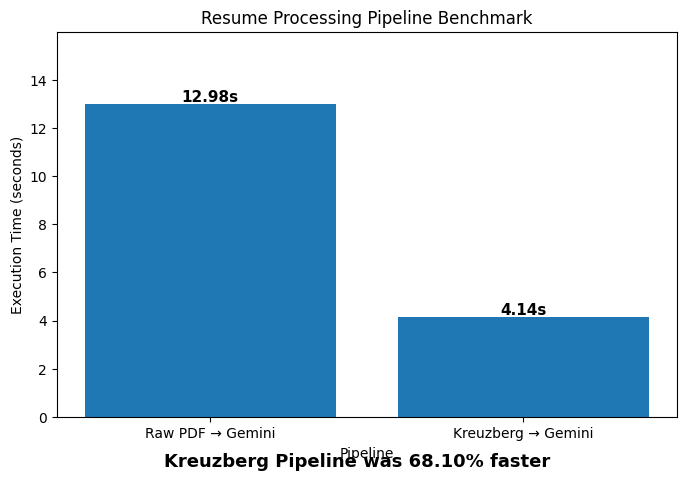

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

comparison_df = pd.DataFrame([
    results_1,
    results_2
])

print("========== FINAL COMPARISON ==========\n")

display(comparison_df)

raw_time = results_1["Execution Time (s)"]
kreuzberg_time = results_2["Execution Time (s)"]

speed_improvement = ((raw_time - kreuzberg_time) / raw_time) * 100

plt.figure(figsize=(8, 5))

bars = plt.bar(
    comparison_df["Pipeline"],
    comparison_df["Execution Time (s)"]
)

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.1,
        f"{height:.2f}s",
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

plt.ylabel("Execution Time (seconds)")
plt.xlabel("Pipeline")
plt.title("Resume Processing Pipeline Benchmark")

plt.ylim(0, max(comparison_df["Execution Time (s)"]) + 3)

plt.figtext(
    0.5,
    0.01,
    f"Kreuzberg Pipeline was {speed_improvement:.2f}% faster",
    ha="center",
    fontsize=13,
    fontweight="bold"
)

plt.show()